# LLaMA 3.2-3B Instruct — qLoRA Fine-tuning on FinancialPhraseBank

## Evaluation on SaguaroCapital Gold Commodity Sentiment Dataset

**Pipeline:**

1. Class imbalance analysis (FinancialPhraseBank)
2. Fine-tune `unsloth/Llama-3.2-3B-Instruct` with qLoRA on **entire** FPB
3. Zero-shot inference on `SaguaroCapital/sentiment-analysis-in-commodity-market-gold`
4. Log metrics to **Langfuse** (compare with FinBERT & FinGPT in the same project)


## 0. Installation


In [4]:
%%capture
import os, re

if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch

    v = re.match(r"[\d]{1,}\.[\d]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + {
        "2.10": "0.0.34",
        "2.9": "0.0.33.post1",
        "2.8": "0.0.32.post2",
    }.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install -U ipywidgets "langfuse>=2.0.0,<3.0.0" scikit-learn matplotlib python-dotenv

## 1. Langfuse Setup

Keys are loaded **automatically** — no hardcoded credentials in this notebook.

| Environment      | Where keys come from                    |
| ---------------- | --------------------------------------- |
| **Google Colab** | Colab Secrets (🔑 icon in left sidebar) |
| **Local**        | `.env` file at repo root                |

**Colab setup (one-time):**

1. Click the 🔑 **Secrets** icon in the Colab left sidebar
2. Add three secrets:
   - `LANGFUSE_PUBLIC_KEY` → your public key
   - `LANGFUSE_SECRET_KEY` → your secret key
   - `LANGFUSE_BASE_URL` → `https://cloud.langfuse.com`
3. Toggle **"Notebook access"** ON for each secret

All three model notebooks share the **same project** — models are separated by tag \
(`finbert`, `llama3.2-3b-qlora`, `fingpt`).


In [5]:
import os
from pathlib import Path

_IN_COLAB = "COLAB_" in "".join(os.environ.keys())


def _load_dotenv_walk(start: Path) -> bool:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return False
    for parent in [start, *start.parents]:
        if (parent / ".env").exists():
            load_dotenv(parent / ".env", override=False)
            print(f"📄 Loaded .env from {parent}")
            return True
    return False


# 1️⃣ Try Colab Secrets (only works in browser UI, not VS Code tunnel)
_secrets_loaded = False
if _IN_COLAB:
    try:
        from google.colab import userdata

        pk = userdata.get("LANGFUSE_PUBLIC_KEY")
        sk = userdata.get("LANGFUSE_SECRET_KEY")
        if pk and sk:
            os.environ["LANGFUSE_PUBLIC_KEY"] = pk
            os.environ["LANGFUSE_SECRET_KEY"] = sk
            os.environ["LANGFUSE_HOST"] = (
                userdata.get("LANGFUSE_BASE_URL") or "https://cloud.langfuse.com"
            )
            _secrets_loaded = True
            print("🔑 Keys loaded from Colab Secrets")
    except Exception:
        pass

# 2️⃣ Fall back to .env (works locally AND when .env is uploaded to Colab)
if not _secrets_loaded:
    _found = _load_dotenv_walk(Path(os.getcwd()))
    if not _found:
        raise FileNotFoundError(
            "No .env found. Upload your .env to the Colab session "
            "(drag it into the Files panel on the left)."
        )

if not os.environ.get("LANGFUSE_HOST") and os.environ.get("LANGFUSE_BASE_URL"):
    os.environ["LANGFUSE_HOST"] = os.environ["LANGFUSE_BASE_URL"]

# Quick connection check via REST
import requests

_host = os.environ.get("LANGFUSE_HOST", "https://cloud.langfuse.com")
_r = requests.get(
    f"{_host}/api/public/health",
    auth=(os.environ["LANGFUSE_PUBLIC_KEY"], os.environ["LANGFUSE_SECRET_KEY"]),
    timeout=10,
)
_r.raise_for_status()
print("✅ Langfuse connected")
print(f"   Host: {_host}")
print(f"   Env:  {'Colab' if _IN_COLAB else 'Local'}")

📄 Loaded .env from /content
✅ Langfuse connected
   Host: https://cloud.langfuse.com
   Env:  Colab


## 2. FinancialPhraseBank — Class Imbalance Analysis


In [6]:
# Download FinancialPhraseBank (75% agreement version)
!curl -L "https://raw.githubusercontent.com/maxwellsarpong/NLP-financial-text-processing-dataset/master/Sentences_75Agree.txt" \
      -o Sentences_75Agree.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  452k  100  452k    0     0   825k      0 --:--:-- --:--:-- --:--:--  826k


In [7]:
import pandas as pd

df = pd.read_csv(
    "Sentences_75Agree.txt",
    sep="@",
    header=None,
    names=["sentence", "label_text"],
    engine="python",
    encoding="latin-1",
)
df["sentence"] = df["sentence"].str.strip()
df["label_text"] = df["label_text"].str.strip().str.lower()

label_to_id = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["label_text"].map(label_to_id)

print(f"Total samples: {len(df)}")
print("\nClass distribution:")
print(df["label_text"].value_counts())

Total samples: 3453

Class distribution:
label_text
neutral     2146
positive     887
negative     420
Name: count, dtype: int64


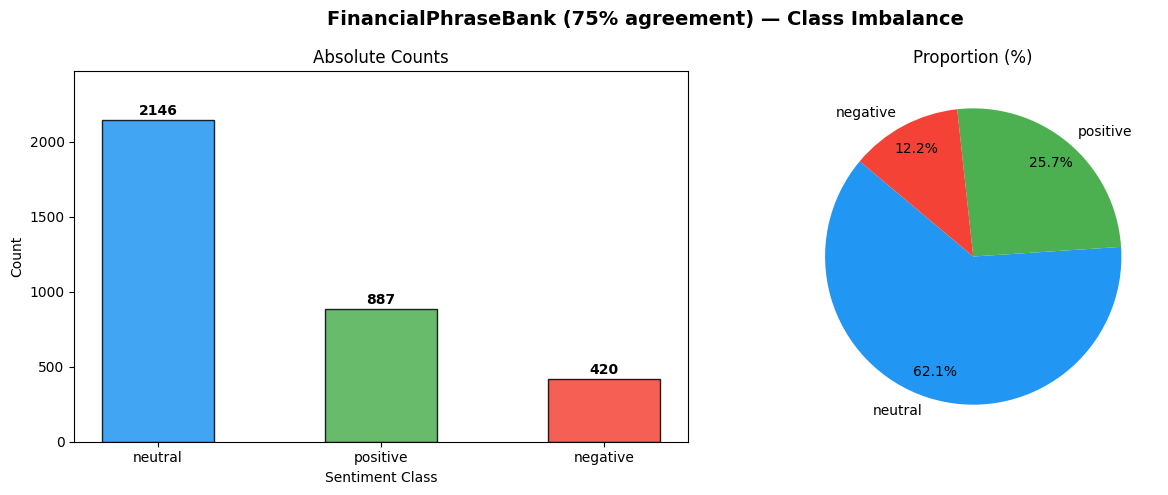


Class Imbalance Summary
  neutral    :  2146  (62.1%)
  positive   :   887  (25.7%)
  negative   :   420  (12.2%)

  Imbalance ratio (largest / smallest): 5.11x

⚠️  Class Imbalance Notes
   • 'neutral' dominates (~60%). A naïve majority-class baseline scores ~60% accuracy
     but ~20% macro F1, exposing the problem.
   • 'negative' is the rarest class — per-class F1 for negative is hardest.
   • ➡  Primary metric: macro F1 (weights all classes equally).
         Secondary metrics: per-class F1, accuracy.



In [8]:
import matplotlib.pyplot as plt
import numpy as np

class_counts = df["label_text"].value_counts()
classes = ["neutral", "positive", "negative"]
counts = [class_counts.get(c, 0) for c in classes]
total = len(df)
percentages = [c / total * 100 for c in counts]
colors = ["#2196F3", "#4CAF50", "#F44336"]  # blue, green, red

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "FinancialPhraseBank (75% agreement) — Class Imbalance",
    fontsize=14,
    fontweight="bold",
)

# Bar chart
bars = ax1.bar(classes, counts, color=colors, edgecolor="black", alpha=0.85, width=0.5)
ax1.set_title("Absolute Counts")
ax1.set_xlabel("Sentiment Class")
ax1.set_ylabel("Count")
for bar, cnt in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        str(cnt),
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax1.set_ylim(0, max(counts) * 1.15)

# Pie chart
wedges, texts, autotexts = ax2.pie(
    counts,
    labels=classes,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82,
)
ax2.set_title("Proportion (%)")

plt.tight_layout()
plt.savefig("fpb_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 50)
print("Class Imbalance Summary")
print("=" * 50)
for cls, cnt, pct in zip(classes, counts, percentages):
    print(f"  {cls:10s} : {cnt:5d}  ({pct:.1f}%)")
print(f"\n  Imbalance ratio (largest / smallest): {max(counts) / min(counts):.2f}x")
print("""
⚠️  Class Imbalance Notes
   • 'neutral' dominates (~60%). A naïve majority-class baseline scores ~60% accuracy
     but ~20% macro F1, exposing the problem.
   • 'negative' is the rarest class — per-class F1 for negative is hardest.
   • ➡  Primary metric: macro F1 (weights all classes equally).
         Secondary metrics: per-class F1, accuracy.
""")

## 3. Load Base Model (Llama 3.2-3B Instruct)


In [9]:
from unsloth import FastLanguageModel
import torch

MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct"
max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=max_seq_length,
    dtype=None,  # auto-detect: fp16 / bf16
    load_in_4bit=True,  # QLoRA 4-bit base
)
print(f"✅ Loaded {MODEL_NAME}")

/tmp/ipykernel_51272/2915893556.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.10: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Loaded unsloth/Llama-3.2-3B-Instruct


## 4. Add QLoRA Adapters (Popular Hyperparameters)


In [10]:
# ── QLoRA hyperparameters (well-established defaults) ────────────────────────
LORA_R = 16  # rank — 16 is the standard starting point
LORA_ALPHA = 32  # alpha = 2 * r is the most common rule-of-thumb
LORA_DROPOUT = 0.05  # small dropout for regularisation

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",  # 30% VRAM saving
    random_state=42,
)
model.print_trainable_parameters()

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.3.10 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


## 5. Prepare Training Data (Entire FPB)

We train on **all** FinancialPhraseBank data (no held-out split) because the
cross-domain evaluation is done on the separate Gold Commodity dataset.


In [11]:
from datasets import Dataset
from transformers import AutoTokenizer

# Re-instantiate tokenizer directly (safe after model load)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def _make_chat(sentence: str, label: str = None) -> str:
    """Build a chat-formatted prompt. label=None → inference mode (no answer appended)."""
    messages = [
        {
            "role": "system",
            "content": (
                "You are a financial sentiment classifier. "
                "Reply with exactly one word: positive, negative, or neutral."
            ),
        },
        {
            "role": "user",
            "content": f"Classify the sentiment of this financial sentence:\n{sentence}",
        },
    ]
    if label is not None:
        messages.append({"role": "assistant", "content": label})
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=(label is None),
    )


# Build HF dataset from the *entire* FPB corpus
hf_train_full = Dataset.from_dict(
    {"text": [_make_chat(r["sentence"], r["label_text"]) for _, r in df.iterrows()]}
)

print(f"Training samples (full FPB): {len(hf_train_full)}")
print("\nSample training text:")
print(hf_train_full[0]["text"][:400])

Training samples (full FPB): 3453

Sample training text:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 24 Mar 2026

You are a financial sentiment classifier. Reply with exactly one word: positive, negative, or neutral.<|eot_id|><|start_header_id|>user<|end_header_id|>

Classify the sentiment of this financial sentence:
According to Gran , the company has no plans to move all production to 


## 6. Fine-tune with qLoRA (SFTTrainer)

**Training hyperparameters (standard / widely-used):**

| Parameter             | Value      | Rationale                              |
| --------------------- | ---------- | -------------------------------------- |
| Learning rate         | 2e-4       | Standard LoRA LR                       |
| LR scheduler          | cosine     | Smooth decay, widely preferred         |
| Warmup ratio          | 0.03       | ~3% of steps as warmup                 |
| Epochs                | 3          | Enough for small task-specific dataset |
| Batch size            | 4          | Per-device, fits in 16GB VRAM          |
| Gradient accumulation | 4          | Effective batch = 16                   |
| Optimizer             | adamw_8bit | Memory-efficient, standard for LoRA    |
| Weight decay          | 0.01       | Light regularisation                   |


In [12]:
from unsloth.chat_templates import train_on_responses_only
from trl import SFTConfig, SFTTrainer
from transformers import DataCollatorForSeq2Seq
import os

ADAPTER_DIR = "qlora_adapters/llama3.2-3b-fpb-full"

if os.path.isdir(ADAPTER_DIR):
    # ── Adapter already exists — skip training, load directly ────────────────
    print(f"✅ Adapter found at '{ADAPTER_DIR}' — skipping training.")
    print("   Delete the folder and re-run to retrain from scratch.")
    train_result = None
else:
    # ── No saved adapter — run full fine-tuning ───────────────────────────────
    print(f"ℹ️  No adapter at '{ADAPTER_DIR}' — starting fine-tuning ...")
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=hf_train_full,
        dataset_text_field="text",
        max_seq_length=max_seq_length,
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer),
        packing=False,
        args=SFTConfig(
            num_train_epochs=3,
            per_device_train_batch_size=4,
            gradient_accumulation_steps=4,
            learning_rate=2e-4,
            lr_scheduler_type="cosine",
            warmup_ratio=0.03,
            weight_decay=0.01,
            optim="adamw_8bit",
            logging_steps=20,
            save_strategy="epoch",
            output_dir="outputs/llama3.2-3b-fpb-full",
            seed=42,
            report_to="none",
            dataset_num_proc=1,
            fp16=not torch.cuda.is_bf16_supported(),
            bf16=torch.cuda.is_bf16_supported(),
        ),
    )
    trainer = train_on_responses_only(
        trainer,
        instruction_part="<|start_header_id|>user<|end_header_id|>\n\n",
        response_part="<|start_header_id|>assistant<|end_header_id|>\n\n",
    )
    print("▶ Training ...")
    train_result = trainer.train()
    print(f"\n✅ Training complete — final loss: {train_result.training_loss:.4f}")


✅ Adapter found at 'qlora_adapters/llama3.2-3b-fpb-full' — skipping training.
   Delete the folder and re-run to retrain from scratch.


In [13]:
if train_result is not None:
    model.save_pretrained(ADAPTER_DIR)
    tokenizer.save_pretrained(ADAPTER_DIR)
    print(f"✅ Adapter saved → {ADAPTER_DIR}")
else:
    # Load the saved adapter into the current model object
    from peft import PeftModel

    print(f"⏩ Loading adapter from '{ADAPTER_DIR}' ...")
    model.load_adapter(ADAPTER_DIR, adapter_name="default")
    print("✅ Adapter loaded.")
FastLanguageModel.for_inference(model)
model.eval()
print("✅ Model ready for inference.")


⏩ Loading adapter from 'qlora_adapters/llama3.2-3b-fpb-full' ...
✅ Adapter loaded.
✅ Model ready for inference.


## 7. Get Evaluation Dataset from Langfuse

The fixed evaluation dataset was uploaded once via:

```bash
python dataset_creation/create_sentiment_ds.py
```

This section fetches that dataset, runs inference on each item, logs per-item scores, and collects labels for local sklearn metrics.


## 8. Inference Setup — Constrained Decoding

Sets up the model for inference and builds a logits processor that forces output to exactly one of `positive`, `negative`, or `neutral`.


In [ ]:
# ── Reload model from adapter if not already in memory ───────────────────────
import os
import torch
from unsloth import FastLanguageModel

ADAPTER_DIR = "qlora_adapters/llama3.2-3b-fpb-full"
MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct"
max_seq_length = 2048

if "model" not in dir() or model is None:
    print(f"⏩ model not found in memory — reloading from '{ADAPTER_DIR}' ...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=ADAPTER_DIR if os.path.isdir(ADAPTER_DIR) else MODEL_NAME,
        max_seq_length=max_seq_length,
        dtype=None,
        load_in_4bit=True,
    )
    print("✅ Model loaded.")
else:
    print("✅ Model already in memory — skipping reload.")

FastLanguageModel.for_inference(model)
model.eval()
print("✅ Model ready for inference.")


✅ Model already in memory — skipping reload.
✅ Model ready for inference.


In [ ]:
import torch

# Switch to inference mode
FastLanguageModel.for_inference(model)
model.eval()

# ── Constrained decoding: only allow "positive", "negative", "neutral" ────────
LABEL_TOKENS: dict[str, list[int]] = {}
for label in ["positive", "negative", "neutral"]:
    for surface in [label, " " + label, label.capitalize(), " " + label.capitalize()]:
        ids = tokenizer.encode(surface, add_special_tokens=False)
        if len(ids) == 1:
            LABEL_TOKENS.setdefault(label, []).append(ids[0])

ALLOWED_IDS = set(tid for ids in LABEL_TOKENS.values() for tid in ids)
ID_TO_LABEL = {tid: label for label, ids in LABEL_TOKENS.items() for tid in ids}

print("Constrained token map:")
for label, ids in LABEL_TOKENS.items():
    decoded = [tokenizer.decode([i]) for i in ids]
    print(f"  {label}: token ids={ids}  surfaces={decoded}")


class _LabelOnlyProcessor(torch.nn.Module):
    def __call__(self, input_ids, scores):
        mask = torch.full_like(scores, float("-inf"))
        for tid in ALLOWED_IDS:
            mask[:, tid] = scores[:, tid]
        return mask


_processor = _LabelOnlyProcessor()
print("✅ Constrained decoding ready.")


Constrained token map:
  positive: token ids=[31587, 6928, 36590, 45003]  surfaces=['positive', ' positive', 'Positive', ' Positive']
  negative: token ids=[43324, 8389, 39589, 51957]  surfaces=['negative', ' negative', 'Negative', ' Negative']
  neutral: token ids=[60668, 21277, 88007, 59794]  surfaces=['neutral', ' neutral', 'Neutral', ' Neutral']
✅ Constrained decoding ready.


In [18]:
# ── Fetch evaluation dataset from Langfuse & run inference ───────────────────
from langfuse import Langfuse
from tqdm.notebook import tqdm as tqdm_nb
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv(dotenv_path=os.path.join(os.getcwd(), ".env"), override=True)

langfuse = Langfuse(
    public_key=os.environ["LANGFUSE_PUBLIC_KEY"],
    secret_key=os.environ["LANGFUSE_SECRET_KEY"],
    host=os.environ.get(
        "LANGFUSE_HOST",
        os.environ.get("LANGFUSE_BASE_URL", "https://cloud.langfuse.com"),
    ),
)

DATASET_NAME = "gold-commodity-sentiment-eval"
dataset = langfuse.get_dataset(DATASET_NAME)

rows = []
gold_preds = []

for item in tqdm_nb(dataset.items, desc="Inference"):
    sentence = item.input["sentence"]
    label = item.expected_output["label"]

    prompt = _make_chat(sentence)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=1,
            do_sample=False,
            logits_processor=[_processor],
        )
    token_id = out[0][inputs["input_ids"].shape[1]].item()
    pred_label = ID_TO_LABEL.get(token_id, "neutral")

    rows.append({"sentence": sentence, "label_text": label})
    gold_preds.append(pred_label)

eval_df = pd.DataFrame(rows)
print(f"✅ Inference complete — {len(eval_df)} samples")
print(f"True distribution:{eval_df['label_text'].value_counts().to_dict()}")
print(f"Pred distribution: {pd.Series(gold_preds).value_counts().to_dict()}")

Inference:   0%|          | 0/1720 [00:00<?, ?it/s]

✅ Inference complete — 1720 samples
True distribution:{'positive': 881, 'negative': 764, 'neutral': 75}
Pred distribution: {'positive': 795, 'negative': 669, 'neutral': 256}


## 9. Evaluation Metrics

**Primary metric:** Macro F1 — treats all classes equally, robust to class imbalance.  
**Secondary metrics:** Per-class F1 (negative / neutral / positive), Accuracy, MCC.


In [19]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

LABELS = ["negative", "neutral", "positive"]

true_labels = eval_df["label_text"].str.strip().str.lower().tolist()
pred_labels = gold_preds

# ── Core metrics ─────────────────────────────────────────────────────────────
f1_macro = f1_score(
    true_labels, pred_labels, labels=LABELS, average="macro", zero_division=0
)
f1_micro = f1_score(
    true_labels, pred_labels, labels=LABELS, average="micro", zero_division=0
)
f1_weighted = f1_score(
    true_labels, pred_labels, labels=LABELS, average="weighted", zero_division=0
)
f1_neg = f1_score(
    true_labels, pred_labels, labels=["negative"], average="macro", zero_division=0
)
f1_neu = f1_score(
    true_labels, pred_labels, labels=["neutral"], average="macro", zero_division=0
)
f1_pos = f1_score(
    true_labels, pred_labels, labels=["positive"], average="macro", zero_division=0
)
accuracy = accuracy_score(true_labels, pred_labels)
mcc = matthews_corrcoef(true_labels, pred_labels)

report = classification_report(true_labels, pred_labels, labels=LABELS, zero_division=0)

print("=" * 60)
print("LLaMA 3.2-3B (qLoRA) — Gold Commodity Sentiment Eval")
print("=" * 60)
print(report)
print(f"Macro  F1  : {f1_macro:.4f}")
print(f"Micro  F1  : {f1_micro:.4f}")
print(f"Weighted F1: {f1_weighted:.4f}")
print(f"Accuracy   : {accuracy:.4f}")
print(f"MCC        : {mcc:.4f}")
print(f"F1 (neg)   : {f1_neg:.4f}")
print(f"F1 (neu)   : {f1_neu:.4f}")
print(f"F1 (pos)   : {f1_pos:.4f}")

LLaMA 3.2-3B (qLoRA) — Gold Commodity Sentiment Eval
              precision    recall  f1-score   support

    negative       0.95      0.83      0.89       764
     neutral       0.20      0.67      0.30        75
    positive       0.93      0.84      0.88       881

    accuracy                           0.83      1720
   macro avg       0.69      0.78      0.69      1720
weighted avg       0.91      0.83      0.86      1720

Macro  F1  : 0.6905
Micro  F1  : 0.8285
Weighted F1: 0.8592
Accuracy   : 0.8285
MCC        : 0.7180
F1 (neg)   : 0.8876
F1 (neu)   : 0.3021
F1 (pos)   : 0.8819


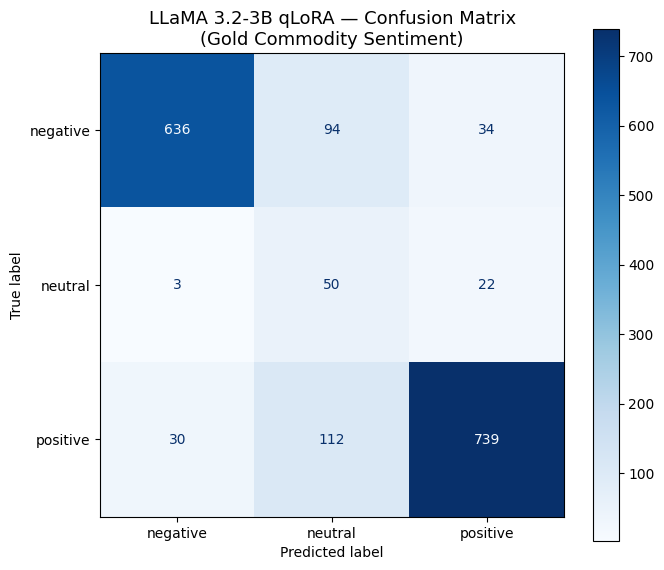

In [20]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels, labels=LABELS)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(
    "LLaMA 3.2-3B qLoRA — Confusion Matrix\n(Gold Commodity Sentiment)", fontsize=13
)
plt.tight_layout()
plt.savefig("confusion_matrix_llama3b.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Clean Up VRAM


In [ ]:
import gc

for _name in ["model", "tokenizer", "trainer"]:
    try:
        del globals()[_name]
    except KeyError:
        pass
gc.collect()
torch.cuda.synchronize()
torch.cuda.empty_cache()
print("🧹 VRAM cleared")


🧹 VRAM cleared
